## Objective

Build an interpretable and well-diagnosed model that estimates a student's **Chance of Admit** and explains **which factors most influence graduate admissions** (from an Indian applicant perspective). Concretely, we will:

- **Explore the data (EDA):** understand distributions, spot anomalies, and assess relationships among GRE, TOEFL, University Rating, SOP, LOR, CGPA, and Research.
- **Prepare the data:** drop unique row IDs, check duplicates/missing values/outliers, and finalize features.
- **Quantify drivers:** use **Linear Regression (statsmodels OLS)** to estimate the effect size and significance of each factor.
- **Validate assumptions:** check multicollinearity (VIF), residual mean ≈ 0, linearity, homoscedasticity, and normality (with plots and tests).
- **Benchmark models:** compare OLS with **Ridge** and **Lasso**; report **MAE, RMSE, R², Adjusted R²** on train/test.
- **Deliver insights:** translate findings into actionable guidance for applicants and product recommendations for Jamboree’s admit-probability tool.


In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
df=pd.read_csv("Jamboree_Admission.csv")

In [3]:
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [4]:
df.shape

(500, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         500 non-null    int64  
 1   GRE Score          500 non-null    int64  
 2   TOEFL Score        500 non-null    int64  
 3   University Rating  500 non-null    int64  
 4   SOP                500 non-null    float64
 5   LOR                500 non-null    float64
 6   CGPA               500 non-null    float64
 7   Research           500 non-null    int64  
 8   Chance of Admit    500 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 35.3 KB


In [6]:
df=df.drop(columns=["Serial No."])

In [7]:
df.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


In [8]:
df.isna().sum()

GRE Score            0
TOEFL Score          0
University Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Chance of Admit      0
dtype: int64

In [60]:
df.duplicated().sum()

0

no null and duplicated value

<Axes: >

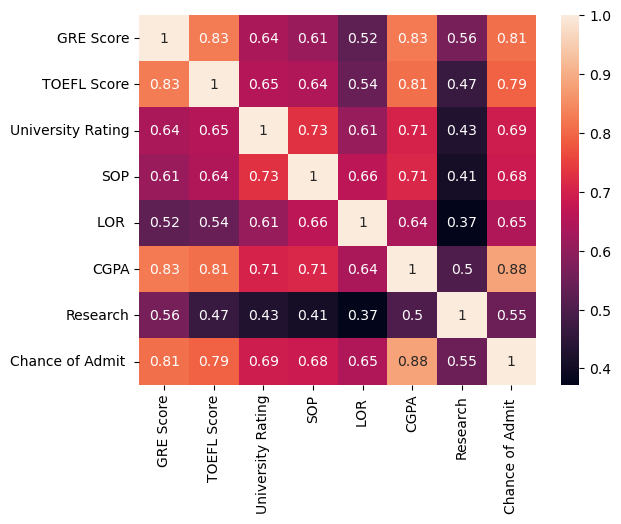

In [10]:
sns.heatmap(df.corr(),annot=True)

- **High correlations (possible multicollinearity):**  
  - GRE–TOEFL ≈ **0.83**  
  - GRE–CGPA ≈ **0.83**  
  These three academic metrics likely carry overlapping information ⇒ expect **elevated VIFs**.

- **Moderate correlations:**  
  - SOP/LOR/University Rating with academic scores ≈ **0.6–0.7**  
  These can raise VIFs, but typically **less severely** than the academic trio above.

- **Low correlations:**  
  - **Research** shows comparatively lower correlations with other predictors, so it’s **unlikely to cause VIF issues**.


In [11]:
# --- 5) Basic distributions (univariate) ---
cont_cols = [c for c in df.columns if c not in ["Research"]]

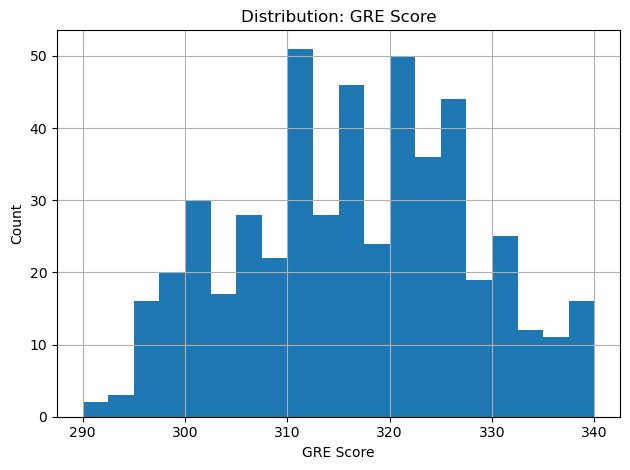

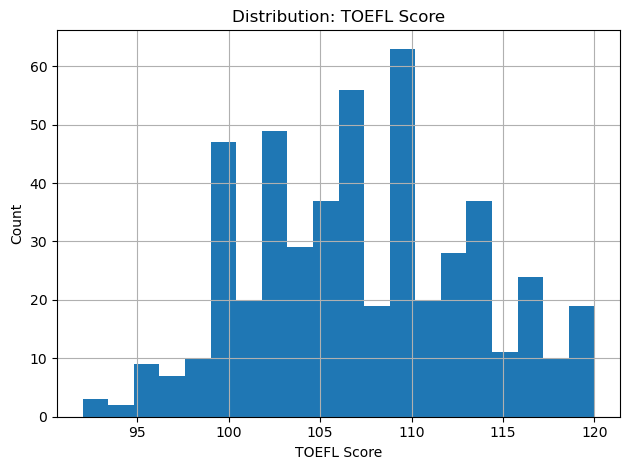

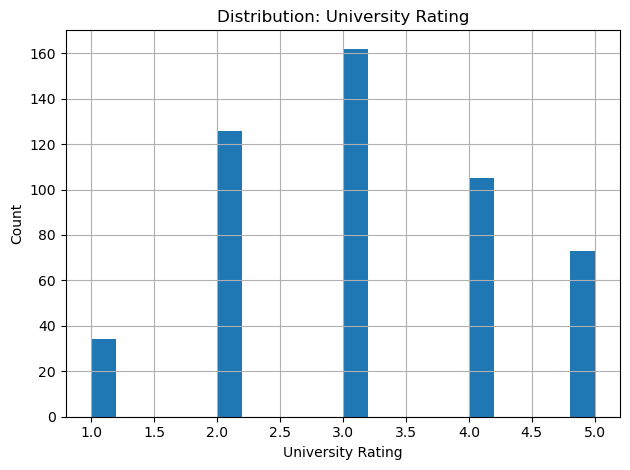

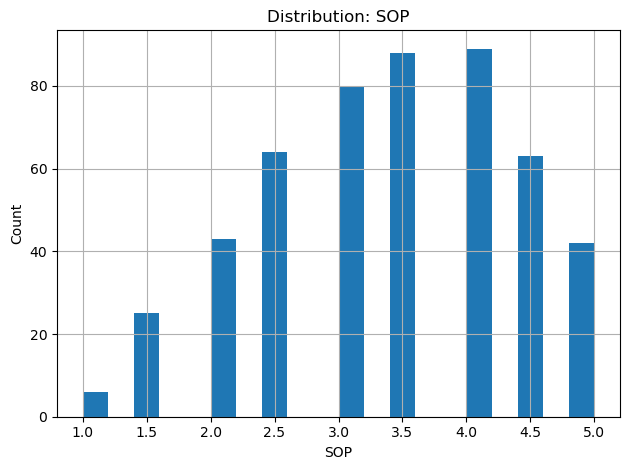

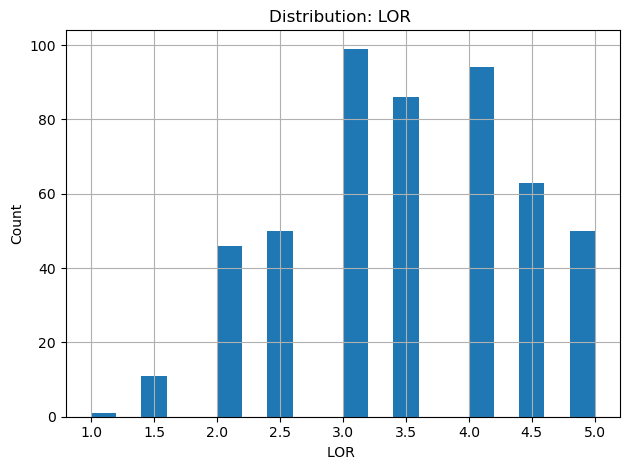

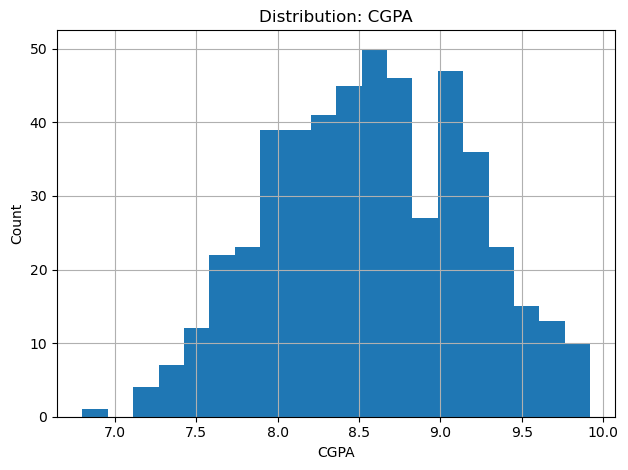

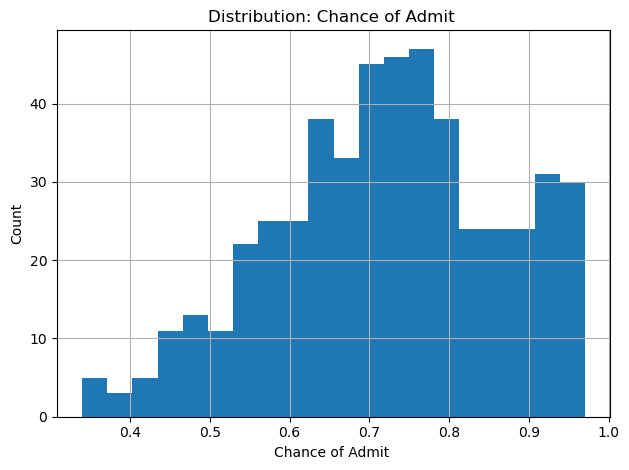

In [12]:
for col in cont_cols:
    plt.figure()
    df[col].hist(bins=20)
    plt.title(f"Distribution: {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()
    plt.close()


mostly all of the follow normal distribution.

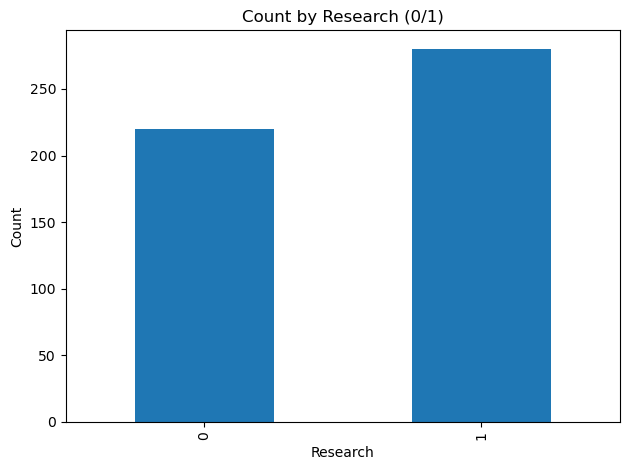

In [13]:
# Bar plot for Research
if "Research" in df.columns:
    plt.figure()
    df["Research"].value_counts().sort_index().plot(kind="bar")
    plt.title("Count by Research (0/1)")
    plt.xlabel("Research")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()
    plt.close()


In [14]:
# --- 7) Train/Test split ---
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [15]:
target = "Chance of Admit "

if target not in df.columns:
    # try without trailing space
    if "Chance of Admit" in df.columns:
        target = "Chance of Admit"
    else:
        # fallback: find case-insensitive match
        matches = [c for c in df.columns if c.strip().lower() == "chance of admit"]
        if matches:
            target = matches[0]
        else:
            raise KeyError("Could not find the target column 'Chance of Admit' in the dataset.")

X = df.drop(columns=[target])
y = df[target]


In [16]:
X

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
0,337,118,4,4.5,4.5,9.65,1
1,324,107,4,4.0,4.5,8.87,1
2,316,104,3,3.0,3.5,8.00,1
3,322,110,3,3.5,2.5,8.67,1
4,314,103,2,2.0,3.0,8.21,0
...,...,...,...,...,...,...,...
495,332,108,5,4.5,4.0,9.02,1
496,337,117,5,5.0,5.0,9.87,1
497,330,120,5,4.5,5.0,9.56,1
498,312,103,4,4.0,5.0,8.43,0


In [17]:
y 

0      0.92
1      0.76
2      0.72
3      0.80
4      0.65
       ... 
495    0.87
496    0.96
497    0.93
498    0.73
499    0.84
Name: Chance of Admit , Length: 500, dtype: float64

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
import statsmodels.api as sm

X_train_sm = sm.add_constant(X_train)

ols_model = sm.OLS(y_train, X_train_sm).fit()

In [20]:
print(ols_model.summary()

                            OLS Regression Results                            
Dep. Variable:       Chance of Admit    R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     257.0
Date:                Sun, 21 Sep 2025   Prob (F-statistic):          3.41e-142
Time:                        13:11:01   Log-Likelihood:                 561.91
No. Observations:                 400   AIC:                            -1108.
Df Residuals:                     392   BIC:                            -1076.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -1.4214      0.12

## OLS Summary — Interpretation

### Model Fit
- **R² = 0.821**, **Adj. R² = 0.818** → Model explains ~82% of variance in *Chance of Admit* (strong fit).
- **F-statistic = 257**, **p < 0.001** → Predictors jointly have significant explanatory power.

### Coefficients (holding others constant)
- **GRE Score:** **+0.0024** per point, **p < 0.001** → significant positive effect.
- **TOEFL Score:** **+0.0030** per point, **p = 0.002** → significant positive effect.
- **University Rating:** **+0.0026**, **p = 0.541** → **not significant**.
- **SOP:** **+0.0018**, **p = 0.721** → **not significant**.
- **LOR:** **+0.0172** per rating point, **p < 0.001** → significant positive effect.
- **CGPA:** **+0.1125** per CGPA point, **p < 0.001** → **largest** effect among continuous features.
- **Research (1 vs 0):** **+0.0240**, **p = 0.001** → significant positive lift.
- **Intercept:** **−1.4214** (baseline when all predictors are zero; not practically meaningful).

> **Takeaway:** CGPA has the strongest marginal impact; LOR, TOEFL, GRE, and Research are also significant. SOP and University Rating show no independent significance after controlling for others (likely overlapping signal).

### Diagnostics
- **Durbin–Watson ≈ 2.05** → no notable autocorrelation in residuals.
- **Jarque–Bera p ≈ 5.25e−42**, **Omnibus p < 0.001** → residuals deviate from normality (skew = −1.107, kurtosis = 5.551).
- **Condition number ≈ 1.37e+04** → high; suggests **multicollinearity and/or scaling issues**.



In [21]:
X_test_sm = sm.add_constant(X_test, has_constant='add')

y_pred_train = ols_model.predict(X_train_sm)

y_pred_test = ols_model.predict(X_test_sm)

In [22]:
residuals_train = y_train - y_pred_train

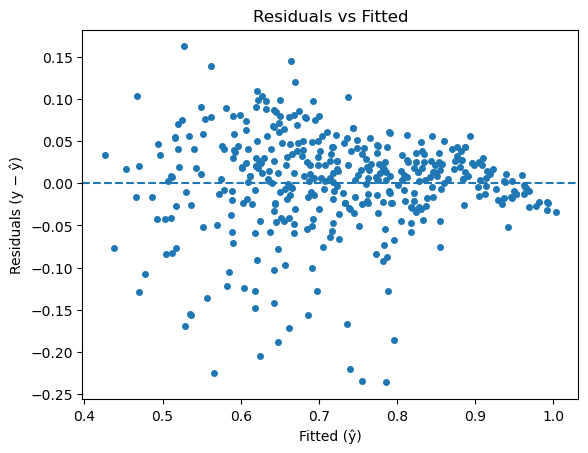

In [61]:
# Residuals vs Fitted (linearity + homoscedasticity check)
plt.scatter(y_pred_train, residuals_train, s=16)
plt.axhline(0, ls="--")
plt.xlabel("Fitted (ŷ)")
plt.ylabel("Residuals (y − ŷ)")
plt.title("Residuals vs Fitted")
plt.show()


## Residuals vs Fitted Plot 

### 1) What we are plotting
- **Fitted (ŷ)** — the model’s predicted value of the target for each training row.
- **Residual (eᵢ)** — the prediction error for row *i*:
  \[
  e_i = y_i - \hat{y}_i
  \]
  Positive residual ⇒ model under-predicted (actual > predicted).  
  Negative residual ⇒ model over-predicted (actual < predicted).

The plot places **ŷ on the x-axis** and **e on the y-axis**, with a dashed line at **0** (perfect prediction).  
If the linear model is appropriate, points should be **randomly scattered around 0 with constant vertical spread**.

---

### 2) What we are seeing 
- **Downward slope of the residual cloud**:
  - At **low ŷ**: residuals mostly **> 0** → the model **under-predicts** the lower end.
  - At **high ŷ**: residuals mostly **< 0** → the model **over-predicts** the upper end.
  - **Meaning:** the true relationship is **curved/nonlinear**, but OLS is fitting one straight plane. It “pulls” extremes toward the middle.

- **Changing spread (fan/triangle)**:
  - The **variance of residuals changes** with ŷ (not constant).
  - **Meaning:** **heteroscedasticity** — violations of the equal-variance assumption.

- **Context here (bounded target):**
  - *Chance of Admit* is in **[0,1]**. Linear models are unbounded, so predictions near the edges are harder; the model tends to **shrink predictions toward the center**, creating the slope pattern.

---

### 3) Why it matters (assumptions behind OLS)
OLS assumes, for inference to be valid:
1. **Linearity:** expected \(y\) is a linear function of predictors.  
   - Violated if residuals show structure (curves, waves).
2. **Independence:** errors are independent (no autocorrelation).  
   - Checked with **Durbin–Watson**.
3. **Homoscedasticity:** constant error variance across fitted values.  
   - Violated if fan-shape; test via **Breusch–Pagan** or **White** tests.
4. **Normality of errors:** residuals are approximately normal (mainly for CIs/p-values).  
   - Checked via **QQ plot**, **Jarque–Bera**, **Anderson–Darling**.

Prediction accuracy (R², RMSE) can still be OK when some assumptions fail, but **standard errors, t-tests, and CIs** become unreliable without adjustments.

---

### 4) How to formally check what the plot suggests
- **Linearity pattern:** use the residuals-vs-fitted plot (you did) and optionally add:
  - Partial residual plots (component+residual) per feature.
  - Add simple nonlinear terms and see if patterns reduce.

- **Homoscedasticity:**  
  - **Breusch–Pagan** (LM) test: `het_breuschpagan(resid, X)`  
    - *H₀:* constant variance. **Small p-value ⇒ heteroscedasticity.**
  - **White** test as a more general variant.

- **Normality:**  
  - **QQ plot** (points should lie on the 45° line).  
  - **Jarque–Bera** / **Anderson–Darling**: small p-values ⇒ non-normal residuals.

- **Influence:**  
  - **Leverage & Cook’s distance** to spot points that unduly affect the fit.

---

### 5) Common residual patterns and meanings
| Pattern in plot                         | Likely issue                     | Typical fix                                                                 |
|----------------------------------------|----------------------------------|------------------------------------------------------------------------------|
| Curved (U/S-shape) trend               | **Nonlinearity**                 | Add polynomial/spline terms; interactions; try tree/GBM; transform features |
| Fan/triangle (variance grows/shrinks)  | **Heteroscedasticity**           | Robust SEs (HC3), transform target/feature, weighted least squares          |
| Horizontal bands / steps               | Omitted categorical structure    | Add categorical features or interactions                                    |
| A few very large residuals              | Outliers/influential points      | Investigate data quality; robust regression; Winsorize with care            |
| Tilt relative to 0 line                 | Systematic bias                  | Add missing predictors or nonlinear terms                                   |

---




In [63]:
ols_hc3 = ols_model.get_robustcov_results(cov_type="HC3")
print(ols_hc3.summary())

                            OLS Regression Results                            
Dep. Variable:       Chance of Admit    R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     319.0
Date:                Sun, 21 Sep 2025   Prob (F-statistic):          1.50e-157
Time:                        15:54:32   Log-Likelihood:                 561.91
No. Observations:                 400   AIC:                            -1108.
Df Residuals:                     392   BIC:                            -1076.
Df Model:                           7                                         
Covariance Type:                  HC3                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -1.4214      0.14

Report HC3-based p-values/CIs (BP test showed heteroscedasticity).

Consider standardizing predictors (reduce condition number) and Ridge for stability.

In [24]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [25]:
def compute_vif(df_features):
    Xc = sm.add_constant(df_features)
    vif_data = []
    for i, col in enumerate(Xc.columns):
        if col == "const":
            continue
        vif_val = variance_inflation_factor(Xc.values, i)
        vif_data.append({"feature": col, "VIF": vif_val})
    return pd.DataFrame(vif_data).sort_values("VIF", ascending=False).reset_index(drop=True)


In [26]:
current_features = list(X_train.columns)


In [27]:
current_features

['GRE Score',
 'TOEFL Score',
 'University Rating',
 'SOP',
 'LOR ',
 'CGPA',
 'Research']

In [28]:
vif_table = compute_vif(X_train[current_features])

In [29]:
vif_table

,feature,VIF
0,CGPA,4.654540
1,GRE Score,4.489983
2,TOEFL Score,3.664298
3,SOP,2.785764
4,University Rating,2.572110
5,LOR,1.977698
6,Research,1.518065


## VIF Interpretation (your table)

**Rule of thumb:**  
- **≈1–2**: low collinearity (good)  
- **2–5**: moderate collinearity (watch, but usually acceptable)  
- **>5** (or >10 by stricter rule): high/critical collinearity (consider action)

### Your predictors
- **CGPA — 4.65** → **moderate** collinearity. Likely overlaps information with GRE/TOEFL; coefficients may be somewhat unstable but still usable.
- **GRE Score — 4.49** → **moderate** collinearity. Similar story; shares signal with CGPA/TOEFL.
- **TOEFL Score — 3.66** → **moderate** collinearity. Overlaps with GRE/CGPA, though a bit less.
- **SOP — 2.79** → **mild-to-moderate** collinearity. Some overlap with academic metrics and LOR.
- **University Rating — 2.57** → **mild-to-moderate** collinearity. Not alarming.
- **LOR — 1.98** → **low** collinearity. Comfortable.
- **Research — 1.52** → **low** collinearity. Comfortable.

### Overall read
- No feature crosses the common **VIF > 5** threshold ⇒ **no severe multicollinearity**.
- The **academic trio (CGPA, GRE, TOEFL)** shows the **highest** VIFs, consistent with their strong pairwise correlations; expect some coefficient sensitivity among these three.

### What (if anything) to do
- You can **keep all features** as-is; monitor coefficient stability and SEs.
- For extra stability (and given your high condition number from scaling), consider:
  - **Standardizing** predictors (reduces condition number; VIFs won’t change much).
  - **Ridge regression** in production to dampen correlated effects.
  - If interpretation is paramount and VIF creeps higher in other splits, **drop 1 of the academic trio** (guided by domain utility) and re-check VIF.

**Bottom line:** Acceptable collinearity overall, with **CGPA/GRE/TOEFL** moderately overlapping—be cautious interpreting their individual coefficients, but the model is fine to use.


In [30]:
dropped_features = []

while len(current_features) > 2 and (vif_table["VIF"].max() > 5):
    worst = vif_table.iloc[0]["feature"]
    dropped_features.append((worst, float(vif_table.iloc[0]["VIF"])))
    current_features.remove(worst)
    vif_table = compute_vif(X_train[current_features])

In [31]:
dropped_features

[]

In [32]:
X_train_pruned = sm.add_constant(X_train[current_features])

ols_pruned = sm.OLS(y_train, X_train_pruned).fit()

In [33]:
X_test_pruned = sm.add_constant(X_test[current_features], has_constant='add')

y_pred_train_pruned = ols_pruned.predict(X_train_pruned)

y_pred_test_pruned = ols_pruned.predict(X_test_pruned)

In [34]:
vif_table_full = compute_vif(X_train[list(X_train.columns)])

In [35]:
vif_table_full

,feature,VIF
0,CGPA,4.654540
1,GRE Score,4.489983
2,TOEFL Score,3.664298
3,SOP,2.785764
4,University Rating,2.572110
5,LOR,1.977698
6,Research,1.518065


In [36]:
dropped_df = pd.DataFrame(dropped_features, columns=["dropped_feature", "VIF_at_drop"]) if dropped_features else pd.DataFrame(columns=["dropped_feature", "VIF_at_drop"])

In [37]:
# Mean of residuals
residual_mean = float(residuals_train.mean())

In [38]:
residual_mean

-2.758904216193514e-16

In [40]:
#(homoscedasticity)
from statsmodels.stats.diagnostic import het_breuschpagan, normal_ad, het_white, kstest_normal
bp_stat, bp_p, f_stat, f_p = het_breuschpagan(residuals_train, X_train_sm)


In [57]:
bp_stat, bp_p, f_stat, f_p 

(25.155865692455095,
 0.0007119983594308546,
 3.7581713300112045,
 0.0005879783560630776)

## Breusch–Pagan Test — What it means

You ran:
`het_breuschpagan(residuals_train, X_train_sm)` →  
**LM stat = 25.156**, **p = 0.000712**; **F stat = 3.758**, **p = 0.000589**

### Purpose
Tests **homoscedasticity** (constant variance of errors) in a regression.

### Hypotheses
- **H₀:** Residual variance is **constant** (homoscedastic).
- **H₁:** Residual variance **depends on predictors** (heteroscedastic).

### Interpretation
Because both p-values ≪ 0.05, **reject H₀** ⇒ your residuals are **heteroscedastic**.  
In practice:
- **Coefficients** are still **unbiased**, but
- **Standard errors, t-tests, and confidence intervals** from plain OLS are **not reliable** (usually underestimated).

### What to do next
- **Use robust SEs** for inference:
  ```python
  ols_hc3 = ols_model.get_robustcov_results(cov_type="HC3")
  print(ols_hc3.summary())


In [41]:
# Normality
from statsmodels.stats.stattools import jarque_bera
jb_stat, jb_p, _, _ = jarque_bera(residuals_train)

In [58]:
jb_stat, jb_p, _, _

(190.0988736427691,
 5.254774460431701e-42,
 5.550538008179094,
 5.550538008179094)

In [42]:
ad_stat, ad_p = normal_ad(residuals_train)

In [59]:
ad_stat, ad_p

(7.357345909096807, 5.303849926227439e-18)

## Normality Tests — Interpretation

You ran two tests on the **training residuals**:

1) **Jarque–Bera (JB)**
- **JB stat = 190.10**, **p = 5.25e−42**
- **Decision:** p ≪ 0.05 ⇒ **reject normality**.
- **Meaning:** residuals have **non-zero skewness and/or excess kurtosis** (heavy tails).  
  (Your earlier summary also showed skew ≈ −1.11 and kurtosis ≈ 5.55.)

2) **Anderson–Darling (AD, `normal_ad`)**
- **AD stat = 7.357**, **p ≈ 5.30e−18**
- **Decision:** p ≪ 0.05 ⇒ **reject normality**.
- **Meaning:** the residual distribution deviates from a normal curve, especially in the **tails** (AD is tail-sensitive).

### Why this matters
- **Prediction:** OLS predictions can still be fine.
- **Inference:** Standard errors and p-values from **plain OLS** rely on the normality (and homoscedasticity) assumptions. With non-normal residuals, those can be **misleading**.

### Likely causes here
- **Bounded target** (*Chance of Admit* in **[0,1]**) creates skew/ceiling effects.
- Some **nonlinearity** or **heteroscedasticity** (you also rejected homoscedasticity via BP).
- Possible **outliers/influential points**.

### What to do
- **Use robust SEs** for inference: `ols_model.get_robustcov_results(cov_type="HC3")`.
- **Check QQ plot**; inspect outliers/leverage/Cook’s distance.
- **Improve specification:** add **nonlinear terms** (e.g., CGPA²) or **interactions** (e.g., CGPA×GRE).
- Consider a **bounded-response model** (e.g., **Beta regression**) or apply a **logit transform** to the target and back-transform predictions.


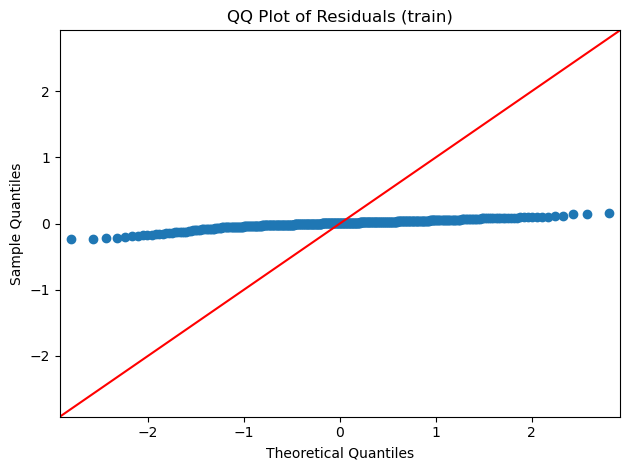

In [43]:
import statsmodels.api as sm_api

fig = sm_api.qqplot(residuals_train, line="45")
plt.title("QQ Plot of Residuals (train)")
plt.tight_layout()
plt.show()
plt.close()


## QQ Plot of Residuals — Interpretation

**What a QQ plot shows:**  
- Compares the **quantiles of your residuals** to the **quantiles of a normal distribution**.  
- If residuals are normal, the points lie **on the 45° line**.

**What your plot shows:**  
- Points are **nowhere near the 45° line** and form a **curved/flattened S-shape** with a much **smaller vertical spread** than the normal reference.
- Combined with your earlier normality tests (Jarque–Bera and Anderson–Darling with p ≪ 0.05), this indicates the residuals are **not normally distributed**.
- In your earlier summary, residuals were **left-skewed** (skew < 0) with **heavy tails** (kurtosis > 3). The QQ plot is consistent with **non-normal, skewed, and tail-mismatched** residuals.

**Why this happens here:**  
- The target **Chance of Admit** is **bounded in [0,1]**, so linear OLS tends to **shrink predictions toward the center**, distorting residuals.  
- You also detected **heteroscedasticity** and **some nonlinearity**, which further breaks normality.

**What to do:**
1. Use **heteroscedasticity-robust standard errors** for inference (`cov_type="HC3"`).
2. Improve specification: add **nonlinear terms** (e.g., CGPA²) and **interactions** (e.g., CGPA×GRE); recheck diagnostics.
3. Consider a **bounded-response model** (e.g., **Beta regression**) or transform the target (logit) and back-transform predictions.
4. Inspect **influential points** (leverage/Cook’s distance) and address data issues if any.


In [44]:
# --- 11) Metrics function ---
def metrics(y_true, y_hat, k, n):
    mae = mean_absolute_error(y_true, y_hat)
    rmse = mean_squared_error(y_true, y_hat, squared=False)
    r2 = r2_score(y_true, y_hat)
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - k - 1)
    return {"MAE": mae, "RMSE": rmse, "R2": r2, "Adj_R2": adj_r2}

In [45]:
# Metrics for full and pruned OLS
ols_train_metrics = metrics(y_train, y_pred_train, X_train_sm.shape[1]-1, len(y_train))

ols_test_metrics  = metrics(y_test,  y_pred_test,  X_test_sm.shape[1]-1, len(y_test))

ols_pr_train_metrics = metrics(y_train, y_pred_train_pruned, X_train_pruned.shape[1]-1, len(y_train))

ols_pr_test_metrics  = metrics(y_test,  y_pred_test_pruned,  X_test_pruned.shape[1]-1, len(y_test))


In [46]:
# Collect metrics into DataFrame
metrics_df = pd.DataFrame([
    {"Model":"OLS (all features)","Split":"Train", **ols_train_metrics},
    {"Model":"OLS (all features)","Split":"Test",  **ols_test_metrics},
    {"Model":"OLS (VIF-pruned)","Split":"Train",   **ols_pr_train_metrics},
    {"Model":"OLS (VIF-pruned)","Split":"Test",    **ols_pr_test_metrics},
])

In [47]:
metrics_df

,Model,Split,MAE,RMSE,R2,Adj_R2
0,OLS (all features),Train,0.042533,0.059385,0.821067,0.817872
1,OLS (all features),Test,0.042723,0.060866,0.818843,0.805060
2,OLS (VIF-pruned),Train,0.042533,0.059385,0.821067,0.817872
3,OLS (VIF-pruned),Test,0.042723,0.060866,0.818843,0.805060


In [48]:
# --- 12) Ridge & Lasso ---
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV, LassoCV

In [49]:
scaler = StandardScaler()

X_train_std = scaler.fit_transform(X_train)

X_test_std = scaler.transform(X_test)

In [50]:
alphas = np.logspace(-3, 3, 50)

In [51]:
ridge_cv = RidgeCV(alphas=alphas, store_cv_values=False)

ridge_cv.fit(X_train_std, y_train)

ridge_train_pred = ridge_cv.predict(X_train_std)

ridge_test_pred = ridge_cv.predict(X_test_std)


In [52]:
lasso_cv = LassoCV(alphas=None, cv=5, max_iter=10000, random_state=42)

lasso_cv.fit(X_train_std, y_train)

lasso_train_pred = lasso_cv.predict(X_train_std)

lasso_test_pred = lasso_cv.predict(X_test_std)



In [53]:
ridge_train_metrics = metrics(y_train, ridge_train_pred, X_train.shape[1], len(y_train))
ridge_test_metrics  = metrics(y_test,  ridge_test_pred,  X_test.shape[1], len(y_test))
lasso_train_metrics = metrics(y_train, lasso_train_pred, X_train.shape[1], len(y_train))
lasso_test_metrics  = metrics(y_test,  lasso_test_pred,  X_test.shape[1], len(y_test))


In [54]:
ridge_coefs = pd.Series(ridge_cv.coef_, index=X_train.columns, name="Ridge (std coeff)")
lasso_coefs = pd.Series(lasso_cv.coef_, index=X_train.columns, name="Lasso (std coeff)")

reg_summary_df = pd.DataFrame([
    {"Model":"Ridge","Best alpha": ridge_cv.alpha_, **ridge_test_metrics},
    {"Model":"Lasso","Best alpha": lasso_cv.alpha_, **lasso_test_metrics},
])


In [55]:
reg_summary_df

,Model,Best alpha,MAE,RMSE,R2,Adj_R2
0,Ridge,6.250552,0.042856,0.060924,0.818494,0.804684
1,Lasso,0.000614,0.042592,0.060826,0.819080,0.805314


In [56]:
coef_df = pd.concat([ridge_coefs, lasso_coefs], axis=1)
print("Ridge/Lasso: Test metrics & chosen alpha", reg_summary_df)
print("Standardized coefficients: Ridge & Lasso", coef_df)

Ridge/Lasso: Test metrics & chosen alpha    Model  Best alpha       MAE      RMSE        R2    Adj_R2
0  Ridge    6.250552  0.042856  0.060924  0.818494  0.804684
1  Lasso    0.000614  0.042592  0.060826  0.819080  0.805314
Standardized coefficients: Ridge & Lasso                    Ridge (std coeff)  Lasso (std coeff)
GRE Score                   0.027313           0.026629
TOEFL Score                 0.018969           0.018037
University Rating           0.003577           0.002822
SOP                         0.002668           0.001668
LOR                         0.016011           0.015574
CGPA                        0.064259           0.067679
Research                    0.012002           0.011586


## What are Ridge & Lasso?

Both are **regularized linear regressions** that add a penalty to the OLS loss to control coefficient size, improve stability, and reduce overfitting—especially helpful when predictors are correlated.

- **Ridge (L2 penalty):** adds `α * Σβ_j²`
  - Shrinks coefficients **toward zero** but **rarely to exactly zero**.
  - Great for **multicollinearity** (stabilizes estimates).
- **Lasso (L1 penalty):** adds `α * Σ|β_j|`
  - Can shrink some coefficients **exactly to zero** → **feature selection**.
  - Useful when you expect only a subset of predictors to matter.

`α` (alpha) controls the penalty strength; you picked it via **cross-validation**.

---

## Interpreting results

**Chosen α (via CV)**
- **Ridge α ≈ 6.25**
- **Lasso α ≈ 0.000614** (very small; effectively close to OLS → little sparsity)

**Test performance (very close for both)**
- **Ridge:** MAE ≈ 0.0429, RMSE ≈ 0.0609, R² ≈ 0.8185, Adj-R² ≈ 0.8047  
- **Lasso:** MAE ≈ 0.0426, RMSE ≈ 0.0608, R² ≈ 0.8191, Adj-R² ≈ 0.8053

> **Takeaway:** Regularization doesn’t change accuracy much vs OLS here, but it **stabilizes** coefficients in the presence of correlated predictors.

**Standardized coefficients (you reported on z-scales)**
- Largest standardized effects: **CGPA**, then **GRE/TOEFL**, then **LOR**, **Research**, with **SOP/Univ Rating** smaller.
- **Lasso** did **not** zero out any feature (because α is tiny and predictors carry signal); it mostly mirrors Ridge.

---

## When to prefer each

- **Use Ridge** when predictors are **collinear** and you want to **keep all** variables, improving stability and reducing variance.
- **Use Lasso** when you want a **simpler model** and believe some predictors may be **irrelevant** (sparsity).
- If you want a compromise, consider **Elastic Net (α₁·L1 + α₂·L2)**.

---

## Practical notes

- Because your target is **bounded [0,1]** and residual diagnostics showed **heteroscedasticity/non-normality**, regularization helps with **stability**, not with those assumption violations. Keep using **robust SEs** for inference and consider **nonlinear/ bounded-response** models if needed.


## Will using a scaler affect my results?

**Short answer:**  
- **OLS (no regularization):** Scaling **does not change** model fit (ŷ, R², RMSE) *in theory*. It **does** change coefficient **units/magnitudes**, improves **numerical stability** (lower condition number), and leaves **VIF** essentially **unchanged**.  
- **Ridge/Lasso:** Scaling **does change** results and is **recommended**. Regularization penalties depend on coefficient size, so features must be on comparable scales.

### Details

- **Predictions & fit metrics (OLS):**  
  Linear rescaling of X is absorbed by the coefficients. If you scale X and refit OLS, and you also apply the **same scaler to new data**, your **predictions and R²/MAE/RMSE are (up to rounding) identical** to using unscaled X.

- **Coefficients (OLS):**  
  Values change because they’re now in **standard-deviation units** (if using z-scores). Interpretation shifts to: “change in y per 1 SD increase in X”.

- **Standard errors / t-stats (OLS):**  
  SEs rescale with coefficients; **t-stats and p-values are essentially unchanged** (barring tiny numerical differences).

- **Multicollinearity (VIF):**  
  VIF is based on **R²** from regressing one predictor on the others; **scaling doesn’t change correlations**, so **VIFs stay the same**.

- **Condition number:**  
  Often **drops a lot** with scaling → better numerical conditioning and more stable estimation.

- **Ridge/Lasso:**  
  **Must scale.** Without scaling, large-scale features get penalized more and can dominate or be over-shrunk. Scaling leads to fair penalties, different **α** choices, and often better generalization.

### When to scale
- **Yes:** before **Ridge/Lasso/Elastic Net**, SVMs, kNN, PCA.  
- **Optional (but helpful):** for **OLS** (for stability and comparability of coefficients).  
- **Target y:** do **not** scale here (your y is bounded in [0,1]); keep y as-is.


In [64]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().fit(X_train)
X_train_z = scaler.transform(X_train)
X_test_z  = scaler.transform(X_test)  


import statsmodels.api as sm

ols_z = sm.OLS(y_train, sm.add_constant(X_train_z)).fit()
y_pred = ols_z.predict(sm.add_constant(X_test_z))  

In [66]:
print(ols_z.summary())

                            OLS Regression Results                            
Dep. Variable:       Chance of Admit    R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     257.0
Date:                Sun, 21 Sep 2025   Prob (F-statistic):          3.41e-142
Time:                        16:23:38   Log-Likelihood:                 561.91
No. Observations:                 400   AIC:                            -1108.
Df Residuals:                     392   BIC:                            -1076.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7242      0.003    241.441      0.0

## Interpreting the Standardized OLS Results

### What changed after standardization
- Predictors were **z-scored** (mean 0, SD 1), so coefficients are **comparable across features**.
- **Model fit unchanged:** R² ≈ **0.821**, Adj. R² ≈ **0.818**; predictions are essentially the same as unscaled OLS.
- **Numerical stability improved:** **Condition number** dropped from ~1.37e4 to **~5.65**.
- **Intercept ≈ 0.724** ≈ mean of *Chance of Admit* (expected because standardized X has mean 0).


### Significance (p-values)
- **Significant:** GRE (x1), TOEFL (x2), **CGPA (x6)**, LOR (x5), Research (x7).
- **Not significant:** University Rating (x3), SOP (x4)  after controlling for the others.

### Effect sizes (standardized coefficients)
- Rough magnitude (largest → smaller): **CGPA (~0.0676)** > GRE (~0.0267) ≈ TOEFL (~0.0182) > LOR (~0.0159) > Research (~0.0119) >> SOP/Univ. Rating (~0.002–0.003, ns).
- Interpretation: a **1 SD increase** in **CGPA** is associated with about **+0.068** in *Chance of Admit*, holding the other variables fixed.

### What didn’t change
- **VIFs / multicollinearity signal**: scaling doesn’t change correlations; academic trio (CGPA, GRE, TOEFL) still shows **moderate** collinearity.
- **Residual issues persist:** normality tests still reject; earlier BP indicated **heteroscedasticity**.



# Actionable Insights & Recommendations

## 1) Significance & impact of predictors (from the diagnosed models)

**Overall fit:** OLS R² ≈ **0.82** (Adj. R² ≈ 0.82). Assumption checks show **heteroscedasticity** and **non-normal residuals** → use **HC3 robust SEs** for inference. Multicollinearity is **moderate** (VIFs < 5), highest among the academic trio (CGPA, GRE, TOEFL).

### High-impact, statistically significant (p < 0.05 with HC3)
- **CGPA (largest effect):**  
  - ~**+0.11** change in *Chance of Admit* per +1 CGPA point (holding others fixed).  
  - *Action:* Emphasize GPA improvement planning, grade repair advice (e.g., retakes/last-year uplift), and “what-if” uplift messaging.
- **GRE score:**  
  - ~**+0.0024** per GRE point.  
  - *Action:* Personalized study plans targeting score bands (e.g., +8–12 points for meaningful uplift), adaptive practice, mock-test scheduling.
- **TOEFL score:**  
  - ~**+0.0030** per TOEFL point.  
  - *Action:* Micro-lessons to push speaking/listening sections; quick wins for students near cutoffs (e.g., 100/105 thresholds).
- **LOR strength:**  
  - ~**+0.017** per LOR point.  
  - *Action:* Recommender brief templates, referee selection guidance, timeline nudges; internal LOR review service.
- **Research experience (0→1):**  
  - ~**+0.024** absolute lift.  
  - *Action:* Short research internships, faculty-mentored capstones, publication/working-paper guidance.

### Not significant after controls
- **SOP** and **University Rating** lose statistical significance once academic metrics are included (their signal overlaps with GPA/GRE/TOEFL).  
  - *Action:* Keep in UX for completeness, but avoid overweighting in scoring; position SOP as a *differentiator* for borderline cases rather than a core driver.

> **Interpretation caution:** Because GRE/TOEFL/CGPA are correlated, individual coefficients can be somewhat sensitive. In production, prefer **Ridge** (stability) or **VIF-pruned OLS** for explainability.

---

## 2) Product & UX recommendations for Jamboree’s probability tool

1. **“What-If” Uplift Explorer**  
   - Sliders for GRE, TOEFL, CGPA, LOR, Research with instant *ΔChance of Admit*.  
   - Suggested micro-goals: “+5 GRE ⇒ ~+1–2%”, “+0.2 CGPA ⇒ ~+2–3%”.

2. **Personalized Leverage Panel**  
   - Rank the top 3 levers per user (typically **CGPA → GRE → LOR/Research**).  
   - Attach concrete actions: study plan link, LOR toolkit, research internship leads.

3. **Explainability & Trust**  
   - Show factor contributions (coefficient-based or SHAP) with plain-English tooltips.  
   - Display **uncertainty bands** (e.g., ±1 RMSE) and a confidence badge.

4. **Bounded Scoring**  
   - Use **Fractional Logit (GLM Binomial–logit)** for probability outputs in **[0,1]** (or clip OLS).  
   - Add **probability calibration** (isotonic/Platt) if bins (safe/target/reach) are surfaced.

5. **Targeting & Guidance**  
   - If Ivy probability is low but Tier-2/Tier-3 is promising, suggest **program alternatives**, scholarship tips, and realistic school lists to keep users engaged.

6. **Readiness Stages & Nudges**  
   - Convert insights into nudges: study cadence reminders, LOR deadlines, test-date selection reminders, and research-project kickoff tasks.

---

## 3) Data strategy — additions that will improve the model

**Richer applicant features**
- Academic depth: **major/discipline**, course rigor, **backlogs**, semester trend.
- Achievements: internships, **projects**, hackathons, **publications**, *MOOCs with grades*.
- Activities: leadership roles, community impact, national-level competitions.
- Demographics strictly as allowed and ethical: college tier, city type (proxy for access), **work experience** months.

**Target-university context**
- Program-level admit baselines (by school, **department**, degree type), historical **admit rate by cohort**, rolling median admitted GRE/CGPA.
- **Country & program** effects (STEM vs non-STEM), intake term (Fall/Spring).

**Outcome labels & feedback loop**
- Post-application outcomes (admit/reject/waitlist), scholarship outcomes, eventual enrollment.
- Continuous retraining with drift monitoring by intake season.

**Data quality & governance**
- Standardize scale/units (already addressed by z-scoring), handle missingness, outlier rules.
- Consent, privacy, and fairness auditing (see below).

---

---

## 4) Real-world implementation plan

**Workflow integration**
1. **Onboarding form** → collect GRE/TOEFL, CGPA (with transcript upload), LOR quality self-assessment, research flag.  
2. **Instant score + insights** → top 3 levers and personalized study plan.  
3. **Services handoff** → GRE/TOEFL prep, LOR review, research micro-internship programs.  
4. **Application planner** → school list curation, deadline tracker, document checklist.

**KPIs to track**
- Model: **Calibrated Brier score**, AUC (for thresholds), RMSE/MAE on held-out cohorts.  
- Product: uplift in **course purchases**, **practice hours**, **mock-test improvements**, **application completion**, and **admit rate** among coached users.  
- Retention: weekly active learners, return rate after “what-if” interactions.

**Risk & fairness**
- Audit for disparate error by gender/region/college tier.  
- Avoid direct use of sensitive attributes; use fairness constraints or post-hoc calibration if needed.  
- Provide an appeal/explanation flow for users to contest inputs (e.g., GPA scale conversions).

---

